In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")


In [23]:
cols_to_drop = ['instant','dteday','yr','casual','registered']

day = day.drop(cols_to_drop, axis=1)
hour = hour.drop(cols_to_drop, axis=1)


In [24]:
day.isnull().sum()
hour.isnull().sum()

day = day.dropna()
hour = hour.dropna()


In [25]:
day = day.drop_duplicates()
hour = hour.drop_duplicates()


In [26]:
day.info()
hour.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB
<class 'pandas.core.frame.DataFrame'>
Index: 17377 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17377 non-null  int64  
 1   mnth        17377 non-null  int64  
 2   hr          17377 non-null  int64  
 3

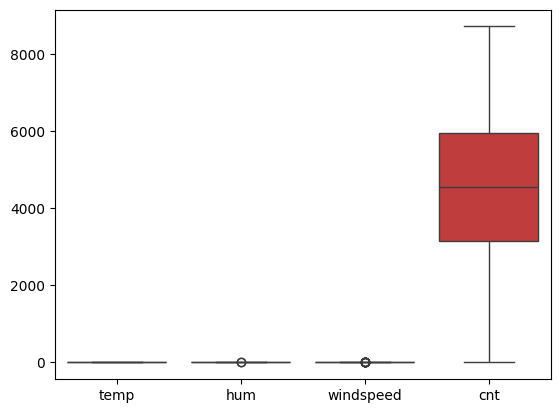

In [27]:
sns.boxplot(data=day[['temp','hum','windspeed','cnt']])
plt.show()


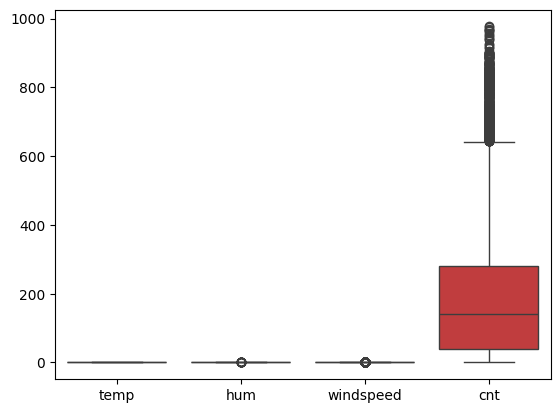

In [28]:
sns.boxplot(data=hour[['temp','hum','windspeed','cnt']])
plt.show()


In [29]:
def clean_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]


In [30]:
for c in ['temp','hum','windspeed','cnt']:
    day = clean_outliers(day, c)
    hour = clean_outliers(hour, c)


In [31]:
day.head(); day.describe(); day.info()
hour.head(); hour.describe(); hour.info()


<class 'pandas.core.frame.DataFrame'>
Index: 717 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      717 non-null    int64  
 1   mnth        717 non-null    int64  
 2   holiday     717 non-null    int64  
 3   weekday     717 non-null    int64  
 4   workingday  717 non-null    int64  
 5   weathersit  717 non-null    int64  
 6   temp        717 non-null    float64
 7   atemp       717 non-null    float64
 8   hum         717 non-null    float64
 9   windspeed   717 non-null    float64
 10  cnt         717 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 67.2 KB
<class 'pandas.core.frame.DataFrame'>
Index: 16533 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      16533 non-null  int64  
 1   mnth        16533 non-null  int64  
 2   hr          16533 non-null  int64  
 3   ho

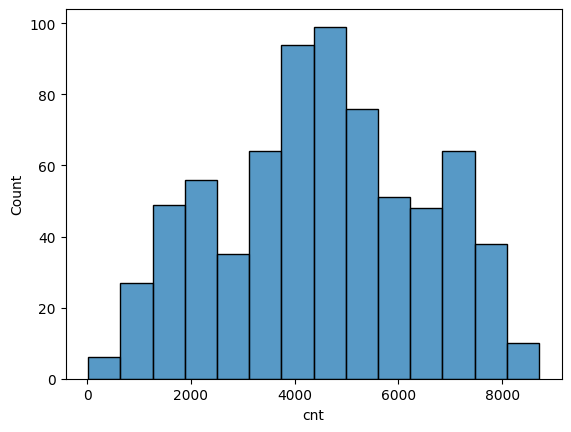

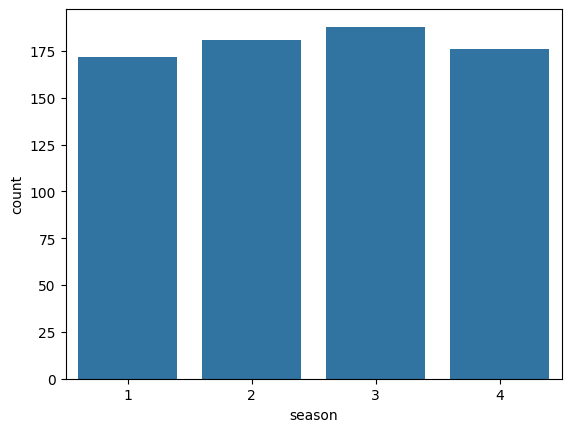

In [32]:
sns.histplot(day['cnt']); plt.show()
sns.countplot(x='season', data=day); plt.show()


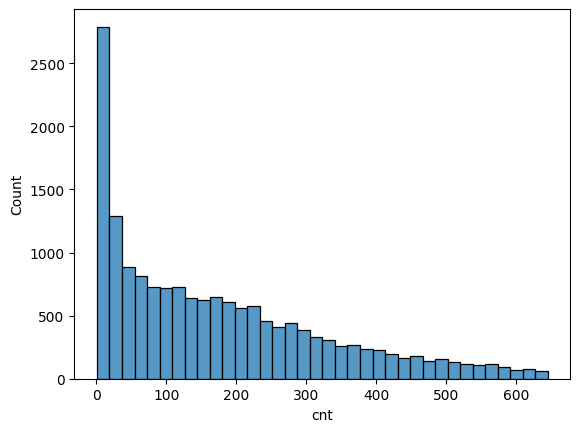

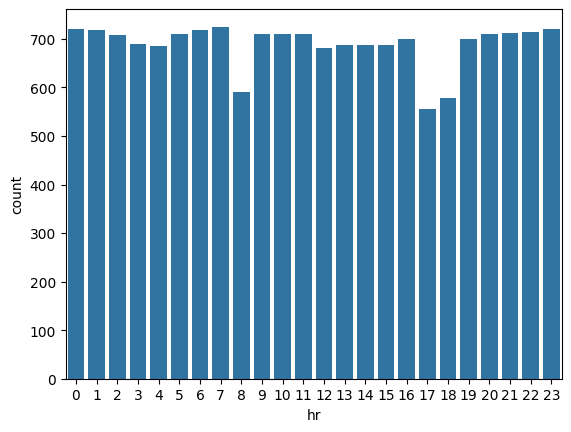

In [33]:
sns.histplot(hour['cnt']); plt.show()
sns.countplot(x='hr', data=hour); plt.show()


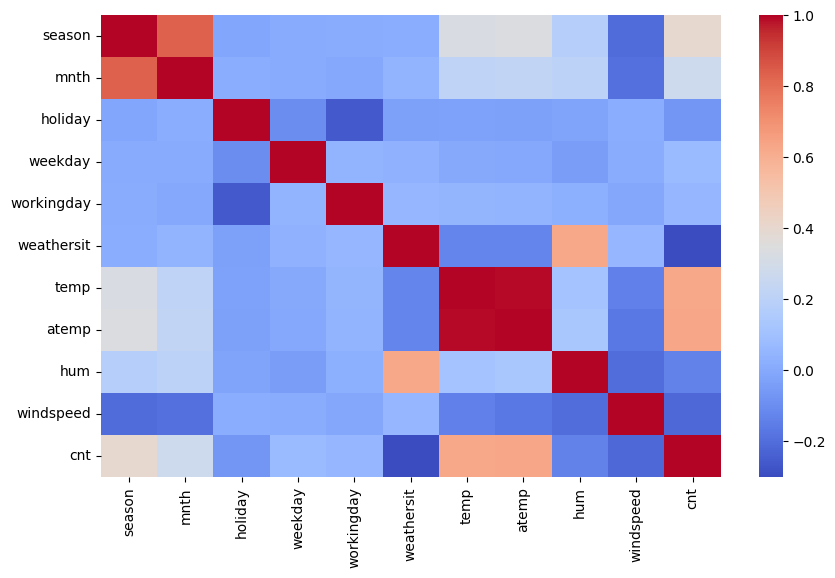

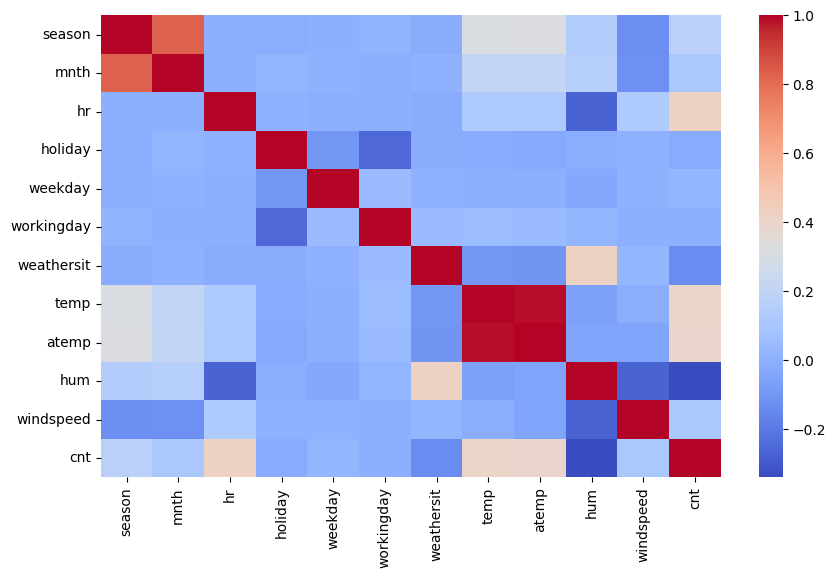

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(day.corr(), cmap="coolwarm")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(hour.corr(), cmap="coolwarm")
plt.show()
